# Fase 1: Exploración y Limpieza

## 1. Exploración Inicial + 2. Limpieza de Datos:

Voy a realizar primero la exploración y limpieza de datos, y posteriormente uniré los dos DF, por lo que haré los 2 puntos de manera enlazada.

In [ ]:
# Importamos las librerías que nos van a hacer falta.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_flight = pd.read_csv('files/Customer Flight Activity.csv')
df_loyalty = pd.read_csv('files/Customer Loyalty History.csv')

In [ ]:
# Vamos a mostrar las primeras 5 líneas de cada DF para hacernos una idea de cómo son (sus columnas, tipos de datos, etc).

df_flight.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [5]:
df_loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [6]:
# Con esta info podemos concluir que todas las columnas de este DF son numéricas y que, en principio, no hay nulos.

df_flight.info()

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [ ]:
# En esta columna en cambio hay datos numéricos, también categóricos y algunas columnas sí que tienen nulos.

df_loyalty.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

In [ ]:
# Vamos a comprobar si hay duplicados (en el caso de loyalty cada cliente debe ser único, y vemos que no hay duplicados).

df_loyalty.duplicated(subset="Loyalty Number").sum()

np.int64(0)

In [9]:
# En flight vemos que se repiten cada año de cada mes, así que debemos indicar esos filtros en la comprobación.

df_flight.duplicated(subset=["Loyalty Number", "Year", "Month"]).sum()

np.int64(3936)

In [ ]:
# Podemos ver que incluso aplicando esos filtros existen duplicados que debemos eliminar. 

df_flight[df_flight.duplicated(subset=["Loyalty Number", "Year", "Month"], keep=False)]

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
41,101902,2017,1,0,0,0,0,0.0,0,0
42,101902,2017,1,0,0,0,0,0.0,0,0
114,106001,2017,1,9,4,13,1365,136.0,0,0
115,106001,2017,1,5,0,5,910,91.0,0,0
226,112142,2017,1,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
405437,989528,2018,12,0,0,0,0,0.0,0,0
405451,990512,2018,12,15,5,20,2940,294.0,0,0
405452,990512,2018,12,5,2,7,3906,390.0,0,0
405486,992168,2018,12,15,0,15,3120,312.0,0,0


In [11]:
# Dado que la regla parece ser que el primero que aparece tiene más datos que el segundo, vamos a quedarnos con la primera fila de cada uno.

df_flight = df_flight.drop_duplicates(subset=["Loyalty Number", "Year", "Month"], keep="first")

In [ ]:
# Vemos que efectivamente el número de entradas ha disminuido al eliminar los duplicados.

df_flight.info()

<class 'pandas.DataFrame'>
Index: 401688 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               401688 non-null  int64  
 1   Year                         401688 non-null  int64  
 2   Month                        401688 non-null  int64  
 3   Flights Booked               401688 non-null  int64  
 4   Flights with Companions      401688 non-null  int64  
 5   Total Flights                401688 non-null  int64  
 6   Distance                     401688 non-null  int64  
 7   Points Accumulated           401688 non-null  float64
 8   Points Redeemed              401688 non-null  int64  
 9   Dollar Cost Points Redeemed  401688 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 33.7 MB


In [ ]:
# Ahora vamos a comprobar si hay nulos.

df_flight.isnull().sum()

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

In [14]:
# Vemos que en loyalty sí que hay nulos.

df_loyalty.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [15]:
# Los nulos de Cancellation Year y Cancellation Month no son un problema porque significan que el cliente sigue teniendo la membresía activa, pero crearemos una columna que nos indique el estado de la membresía.
# Los nulos en Salary sí que suponen un problema, vamos a revisarlo bien para poder tomar una decisión.

df_loyalty["Salary"].isnull().sum() / len(df_loyalty) * 100

np.float64(25.321144769074504)

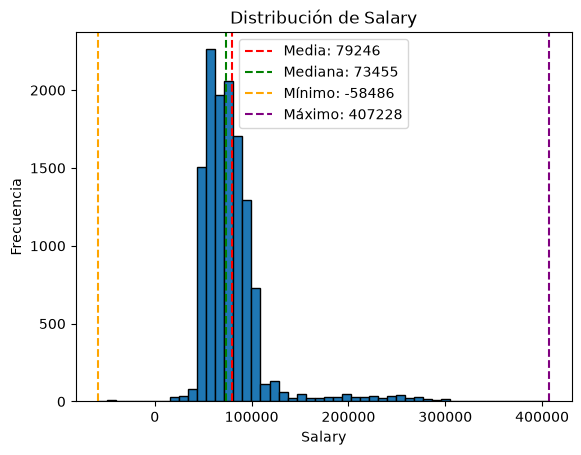

In [16]:
fig, ax = plt.subplots()

ax.hist(df_loyalty["Salary"], bins=50, edgecolor="black")

ax.axvline(df_loyalty["Salary"].mean(), color="red", linestyle="--", label=f'Media: {df_loyalty["Salary"].mean():.0f}')
ax.axvline(df_loyalty["Salary"].median(), color="green", linestyle="--", label=f'Mediana: {df_loyalty["Salary"].median():.0f}')
ax.axvline(df_loyalty["Salary"].min(), color="orange", linestyle="--", label=f'Mínimo: {df_loyalty["Salary"].min():.0f}')
ax.axvline(df_loyalty["Salary"].max(), color="purple", linestyle="--", label=f'Máximo: {df_loyalty["Salary"].max():.0f}')

ax.set_title("Distribución de Salary")
ax.set_xlabel("Salary")
ax.set_ylabel("Frecuencia")
ax.legend()

plt.show()

# Vemos que hay salarios negativos, estos los vamos a tratar como nulos ya que nadie puede cobrar negativo.
# Vemos también que los datos están sesgados a la derecha, hay valores extremos muy por encima de los valores centrales. Esto hace que la media de salarios esté inflada.
# Dado que el porcentaje de nulos es bajo y en distribuciones asimétricas la mediana es más representativa del valor central, imputaremos los nulos con la mediana.

In [ ]:
# Primero convertimos los datos negativos en nulos, para después tratar todos los nulos juntos.

df_loyalty.loc[df_loyalty["Salary"] < 0, "Salary"] = np.nan

In [ ]:
# Ahora vamos a imputar los nulos con la mediana.

df_loyalty["Salary"] = df_loyalty["Salary"].fillna(df_loyalty["Salary"].median())

In [ ]:
# Vamos a verificar que ya no quedan nulos.

df_loyalty["Salary"].isnull().sum()

np.int64(0)

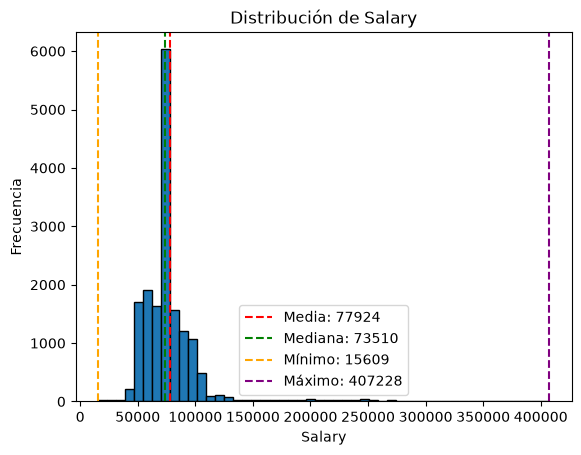

In [ ]:
# Ahora vamos a ver el resultado.

fig, ax = plt.subplots()

ax.hist(df_loyalty["Salary"], bins=50, edgecolor="black")

ax.axvline(df_loyalty["Salary"].mean(), color="red", linestyle="--", label=f'Media: {df_loyalty["Salary"].mean():.0f}')
ax.axvline(df_loyalty["Salary"].median(), color="green", linestyle="--", label=f'Mediana: {df_loyalty["Salary"].median():.0f}')
ax.axvline(df_loyalty["Salary"].min(), color="orange", linestyle="--", label=f'Mínimo: {df_loyalty["Salary"].min():.0f}')
ax.axvline(df_loyalty["Salary"].max(), color="purple", linestyle="--", label=f'Máximo: {df_loyalty["Salary"].max():.0f}')

ax.set_title("Distribución de Salary")
ax.set_xlabel("Salary")
ax.set_ylabel("Frecuencia")
ax.legend()

plt.show()

# Vemos que ahora el mínimo ya es un valor positivo. Soy consciente de que imputar con la mediana distorsiona la distribución creando un pico, pero para el análisis posterior es una solución aceptable y simple.

In [ ]:
# Nos falta tratar los nulos de Cancellation Year y Cancellation Month, que hemos dicho que crearemos una columna que nos indique el estado en base a estas columnas.
# Lo hago así porque aquí el nulo es un dato en sí, por lo que no tiene sentido eliminarlo ni imputarlo, para trabajar con una columna sin nulos, creamos otra que interpreta este dato.

df_loyalty["Membership Status"] = df_loyalty["Cancellation Year"].isnull().map({True: "Activa", False: "Cancelada"})

In [22]:
df_loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Membership Status
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,Activa
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73510.0,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,Activa
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73510.0,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,Cancelada
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,73510.0,Single,Star,3839.75,Standard,2013,2,NaN,NaN,Activa
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,Activa


In [23]:
df_loyalty.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              16737 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
 16  Membership Stat

In [24]:
# Una vez gestionada toda la limpieza, vamos a unir los DF.

df_total = df_flight.merge(df_loyalty, on="Loyalty Number", how="left")
df_total.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,...,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Membership Status
0,100018,2017,1,3,0,3,1521,152.0,0,0,...,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Activa
1,100102,2017,1,10,4,14,2030,203.0,0,0,...,73510.0,Single,Nova,2887.74,Standard,2013,3,NaN,NaN,Activa
2,100140,2017,1,6,0,6,1200,120.0,0,0,...,73510.0,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN,Activa
3,100214,2017,1,0,0,0,0,0.0,0,0,...,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN,Activa
4,100272,2017,1,0,0,0,0,0.0,0,0,...,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN,Activa


# Fase 2: Análisis Estadístico

1-. Análisis de variables numéricas:
- Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables numéricas relevantes.
- Identificación de valores atípicos en las variables numéricas.
- Análisis de correlación entre variables numéricas.

In [25]:
columnas_numericas = ["Flights Booked", "Flights with Companions", "Total Flights", "Distance", "Points Accumulated", "Points Redeemed", "Dollar Cost Points Redeemed", "Salary", "CLV"]

df_total[columnas_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Flights Booked,401688.0,4.14,5.23,0.00,0.00,1.00,8.00,21.00
Flights with Companions,401688.0,1.04,2.08,0.00,0.00,0.00,1.00,11.00
Total Flights,401688.0,5.17,6.53,0.00,0.00,1.00,10.00,32.00
Distance,401688.0,1213.78,1434.31,0.00,0.00,518.00,2340.00,6293.00
Points Accumulated,401688.0,124.17,146.68,0.00,0.00,53.00,240.00,676.50
Points Redeemed,401688.0,30.78,125.62,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,401688.0,2.49,10.16,0.00,0.00,0.00,0.00,71.00
Salary,401688.0,77923.60,30095.94,15609.00,63991.00,73510.00,82940.00,407228.00
CLV,401688.0,7988.90,6860.79,1898.01,3980.84,5780.18,8940.58,83325.38


In [26]:
df_total[columnas_numericas].mode().iloc[0]

Flights Booked                     0.00
Flights with Companions            0.00
Total Flights                      0.00
Distance                           0.00
Points Accumulated                 0.00
Points Redeemed                    0.00
Dollar Cost Points Redeemed        0.00
Salary                         73510.00
CLV                             8564.77
Name: 0, dtype: float64

Estos datos nos indican que existen muchísimos clientes inactivos que sesgan nuestros datos. Esto lo sabemos porque la moda en Flights Booked, Distance, Points Accumulated, Points Redeemed y Total Flights es 0.

Vamos a apoyar estos datos con gráficas para ver todo más fácilmente. Para las conclusiones miraremos los datos de la tabla de arriba + las gráficas siguientes.

Voy a utilizar el boxplot porque es la gráfica que más información nos da y que más fácil es de interpretar para mi gusto.

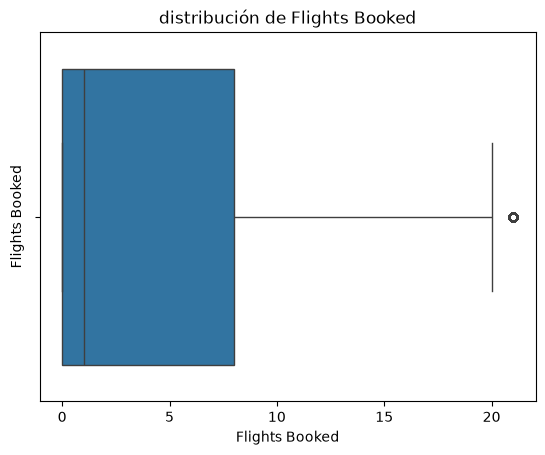

In [28]:
sns.boxplot(data=df_total, x='Flights Booked')
plt.title('distribución de Flights Booked')
plt.ylabel ('Flights Booked')
plt.show()

Flights Booked: Al menos el 25% de los clientes no han viajado.

La mediana de Flights Booked (50% = 1) es muy baja comparada con la media (4.14), eso significa que casi la mitad de los clientes no volaron ese mes. La media está inflada por una minoría de clientes muy activos.

La media de Flights Booked es 4.14 y el 75% de los clientes reserva 8 o menos viajes, si el máximo está en 21, podemos decir que existen posibles valores atípicos (clientes que viajan mucho más que la mayoría).

En la gráfica se puede ver claramente ese valor atípico.

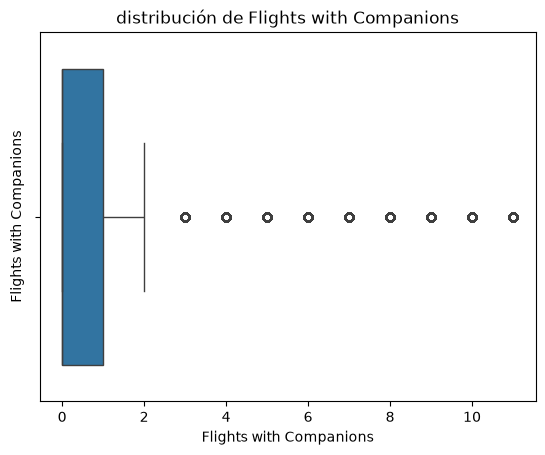

In [29]:
sns.boxplot(data=df_total, x='Flights with Companions')
plt.title('distribución de Flights with Companions')
plt.ylabel ('Flights with Companions')
plt.show()

Flights with Companions: Al menos la mitad de los clientes viajan sin acompañante y la moda también es 0. La media es 1.04. 

El rango intercuartílico (Q3-Q1) es muy estrecho, solo 1 punto, lo que indica que al menos el 75% de los viajeros viaja con 1 acompañante o menos. 

Esto hace que cualquiera que viaje con más de 2 acompañantes se marque como atípico.

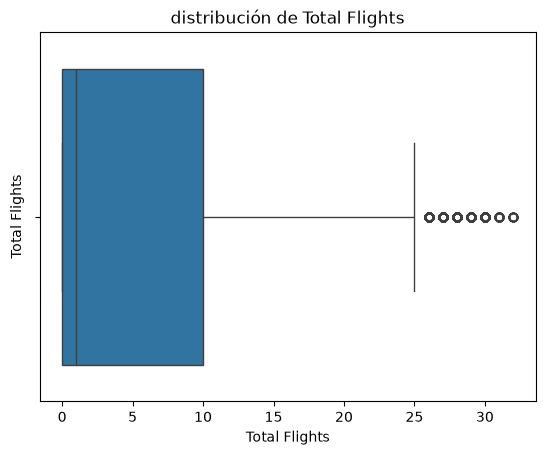

In [30]:
sns.boxplot(data=df_total, x='Total Flights')
plt.title('distribución de Total Flights')
plt.ylabel ('Total Flights')
plt.show()

Total Flights: Tiene el mismo patrón que Flights Booked, caja concentrada entre 0 y 10, mediana pegada en 1, y un puñado de puntos entre 25 y 32 marcados como outliers. 

La media es 5.17, la mediana 1 y el máximo 32. Está muy sesgado por una minoría de viajeros muy activos.

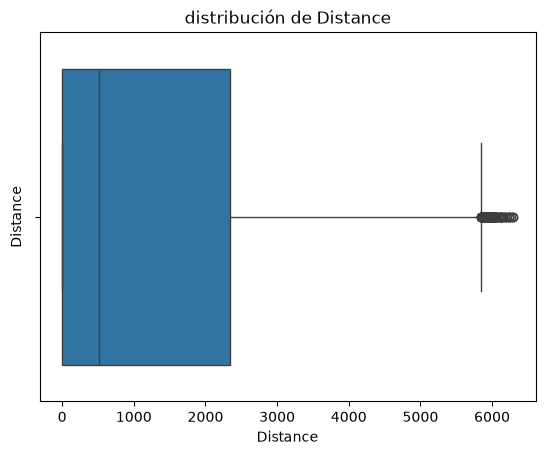

In [31]:
sns.boxplot(data=df_total, x='Distance')
plt.title('distribución de Distance')
plt.ylabel ('Distance')
plt.show()

Distance: La caja (50% central de los datos) va de 0 a 2340, la mediana es 518, eso significa que la mitad de los clientes vuela distancias cortas o no vuela ese mes. El bigote derecho llega hasta unos 5800.

Los puntos entre 5800 y 6293 que quedan fuera del bigote (outliers), son un grupo compacto que hacen viajes más largos que el resto. 

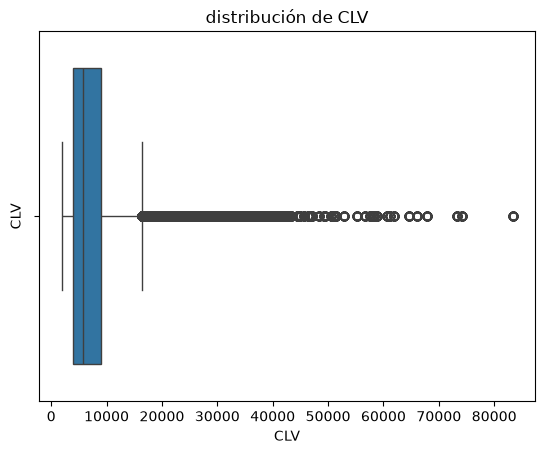

In [32]:
sns.boxplot(data=df_total, x='CLV')
plt.title('distribución de CLV')
plt.ylabel ('CLV')
plt.show()

En el CLV el rango es enorme (min 1898 - max 83325); La caja va de 3980 a 8940,  la media (7988) está muy por encima de la mediana (5780) lo que indica que existe un pequeño grupo de clientes de muy alto valor que inflan estos datos.

Los outliers van de 20000 hasta 83325 con algunos puntos muy aislados en el extremo. 

Como hemos comentado anteriormente, la mayoría de los miembros no viajan, por lo que parece normal que los que sí viajan a menudo aporten un muy alto valor con respecto a los que no viajan (la mayoría), que no aportan ningún valor.

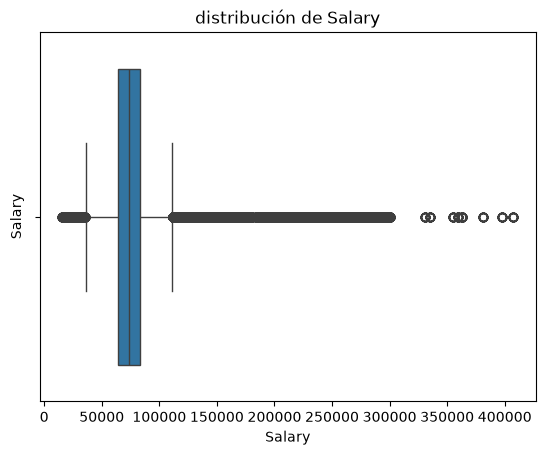

In [33]:
sns.boxplot(data=df_total, x='Salary')
plt.title('distribución de Salary')
plt.ylabel ('Salary')
plt.show()

Salary: La caja va de 63991 a 82940, la mediana es 73510, es decir, el 50% central de los clientes tienen salarios bastante concentrados en ese rango.

Los bigotes llegan hasta unos 20k por la izquierda y unos 130k por la derecha. 

Existe un volumen considerable de outliers, unos cuantos por la izquierda y la gran mayoría por la derecha. La gran mayoría se acumulan entre 130k y 300k y luego hay unos casos aislados entre 300k y 407228.

Dado que la imputación de la mediana creó un pico artificial, parte de esa masa densa de outliers pueden ser fruto de esa imputación.

In [34]:
columnas_numericas = ["Flights Booked", "Flights with Companions", "Total Flights", "Distance", "Points Accumulated", "Points Redeemed", "Dollar Cost Points Redeemed", "Salary", "CLV"]

df_total[columnas_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Flights Booked,401688.0,4.14,5.23,0.00,0.00,1.00,8.00,21.00
Flights with Companions,401688.0,1.04,2.08,0.00,0.00,0.00,1.00,11.00
Total Flights,401688.0,5.17,6.53,0.00,0.00,1.00,10.00,32.00
Distance,401688.0,1213.78,1434.31,0.00,0.00,518.00,2340.00,6293.00
Points Accumulated,401688.0,124.17,146.68,0.00,0.00,53.00,240.00,676.50
Points Redeemed,401688.0,30.78,125.62,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,401688.0,2.49,10.16,0.00,0.00,0.00,0.00,71.00
Salary,401688.0,77923.60,30095.94,15609.00,63991.00,73510.00,82940.00,407228.00
CLV,401688.0,7988.90,6860.79,1898.01,3980.84,5780.18,8940.58,83325.38


## - Análisis de correlación entre variables numéricas.

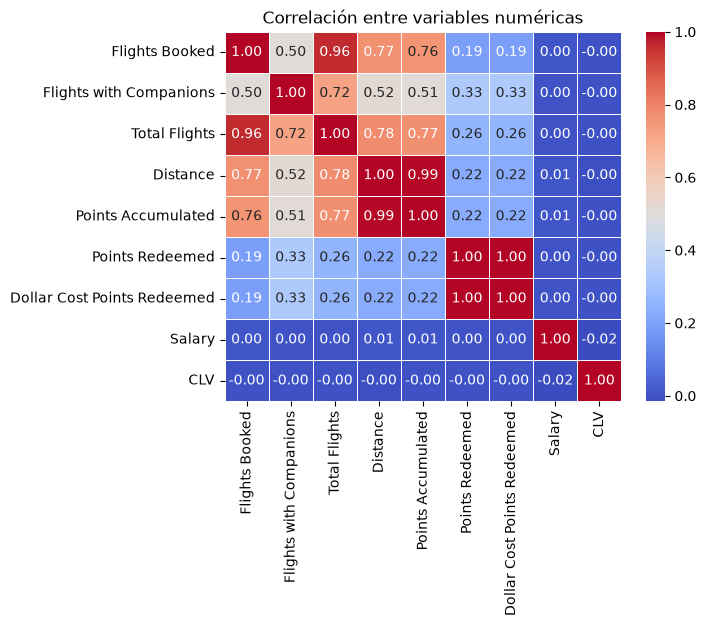

In [35]:
num_variables = df_total[columnas_numericas].select_dtypes(include=np.number).columns.to_list()
correlacion_matriz = df_total[num_variables].corr()

fig, ax = plt.subplots()
sns.heatmap(correlacion_matriz, annot=True, cmap='coolwarm', linewidths=.5, fmt='.2f')
ax.set_title("Correlación entre variables numéricas")
plt.show()

Correlaciones muy altas:
- Distance y Points Accumulated: 0.99 lo que nos indica que cuanto mayor sea la distancia del vuelo, más puntos se acumulan.
- Points Redeemed y Dollar Cost Points Redeemed: 1.00 con lo que deducimos que son la misma variable expresada de dos formas distintas (puntos vs valor en dólares). Tener las dos en el análisis es redundante.
- Flights Booked y Total Flights: 0.96 es normal que estén muy relacionadas, significa que los clientes que reservan un vuelo rara vez lo cancelan.

Correlaciones moderadas:
- Flights Booked con Distance (0.77) y Points Accumulated (0.76), cuantos más vuelos, más distancia y más puntos.
- Flights with Companions tiene correlaciones moderadas con casi todo (0.50-0.72), viajar con acompañantes se relaciona con volar más, pero no de forma determinante.

Correlaciones prácticamente nulas:
- Salary y CLV con todo. El salario y el valor del cliente no tienen relación con la actividad de vuelo en este dataset. Esto es sorprendente: cabría esperar que clientes con mayor salario volaran más, pero los datos no lo confirman.

# 2-. Análisis de variables categóricas:

In [36]:
# Tras elegir qué columnas con valores categóricos son relevantes para el análisis, vamos a mostrar primero sus datos de forma general para después elegir con qué gráficas lo leeremos mejor.

columnas_categoricas = ["Gender", "Education", "Marital Status", "Loyalty Card", "Enrollment Type", "Membership Status", "Province"]

for col in columnas_categoricas:
    print(df_total[col].value_counts())
    print("---")

Gender
Female    201840
Male      199848
Name: count, dtype: int64
---
Education
Bachelor                251400
College                 101712
High School or Below     18768
Doctor                   17616
Master                   12192
Name: count, dtype: int64
---
Marital Status
Married     233640
Single      107616
Divorced     60432
Name: count, dtype: int64
---
Loyalty Card
Star      183288
Nova      136104
Aurora     82296
Name: count, dtype: int64
---
Enrollment Type
Standard          378384
2018 Promotion     23304
Name: count, dtype: int64
---
Membership Status
Activa       352080
Cancelada     49608
Name: count, dtype: int64
---
Province
Ontario                 129696
British Columbia        105816
Quebec                   79200
Alberta                  23256
Manitoba                 15792
New Brunswick            15264
Nova Scotia              12432
Saskatchewan              9816
Newfoundland              6192
Yukon                     2640
Prince Edward Island      1584
Name

- Vamos a usar el gráfico de barras para Education, Marital Status y Province porque tienen muchas categorías y se ven mejor y más ordenados.
- Para Gender, Loyalty Card, Enrollment Type, Membership Status usaremos la tarta o quesito, ya que tienen pocas categorías y se ven mejor las proporciones.

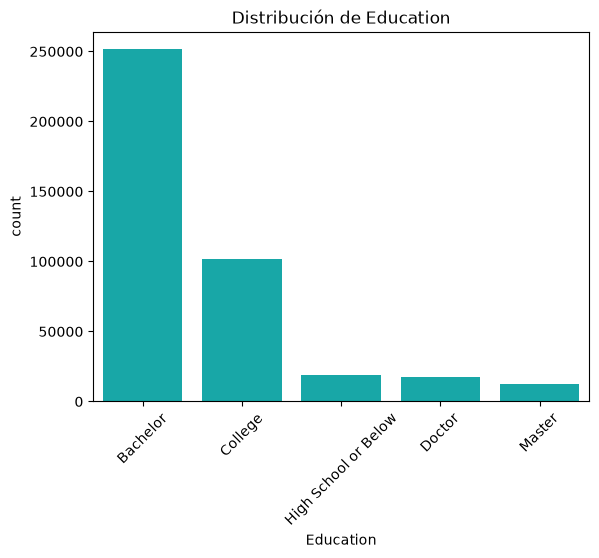

In [37]:
order_education = df_total["Education"].value_counts().index
sns.countplot(x="Education", data=df_total, color="c", order=order_education)
plt.title("Distribución de Education")
plt.xticks(rotation=45)
plt.show()

La mayoría de clientes del programa tiene estudios universitarios, domina con 251400 registros, seguido de College con 101712. Los niveles de posgrado (Master, Doctor) y High School or Below tienen una presencia marginal.

Conclusión: el programa de lealtad atrae principalmente a clientes con formación universitaria, lo que puede ser relevante para estrategias de comunicación y beneficios orientados a ese perfil.

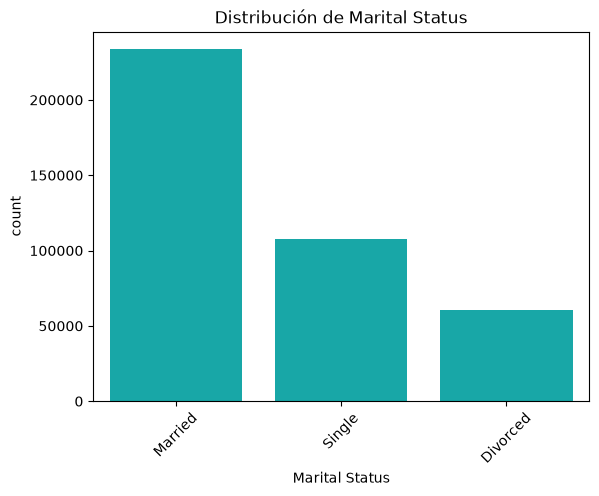

In [38]:
order_marital_status = df_total["Marital Status"].value_counts().index
sns.countplot(x="Marital Status", data=df_total, color="c", order=order_marital_status)
plt.title("Distribución de Marital Status")
plt.xticks(rotation=45)
plt.show()

Los clientes casados dominan el programa con 233640 registros, más del doble que los solteros (107616) y casi cuatro veces más que los divorciados (60432).

Conclusión: el perfil típico del cliente del programa de lealtad es una persona casada con estudios universitarios.

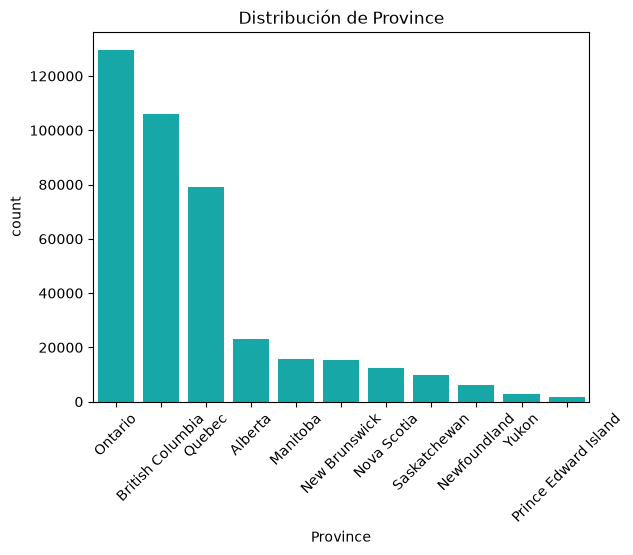

In [39]:
order_province = df_total["Province"].value_counts().index
sns.countplot(x="Province", data=df_total, color="c", order=order_province)
plt.title("Distribución de Province")
plt.xticks(rotation=45)
plt.show()

Ontario lidera con 129696 registros, seguido de British Columbia (105816) y Quebec (79200). Las tres provincias más pobladas de Canadá concentran la gran mayoría de clientes del programa. El resto de provincias tienen presencia marginal. 

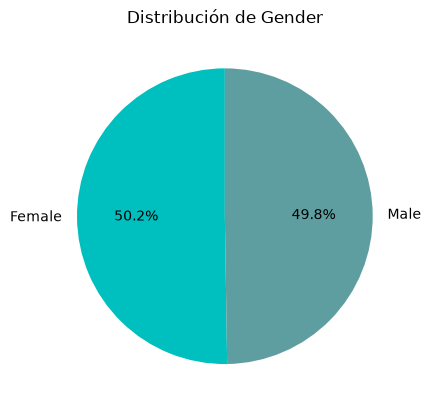

In [40]:
df_gender = df_total.groupby("Gender")["Loyalty Number"].count().reset_index()

colores = ["c", "cadetblue"]
plt.pie(x="Loyalty Number", data=df_gender, labels="Gender", autopct="%1.1f%%", colors=colores, startangle=90)
plt.title("Distribución de Gender")
plt.show()

La distribución de género es prácticamente equitativa, 50.2% mujeres y 49.8% hombres. No hay sesgo de género en el programa de lealtad.

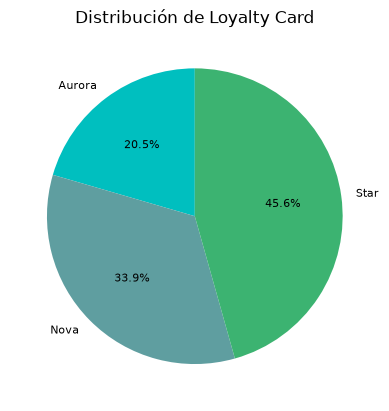

In [41]:
df_loyalty_card = df_total.groupby("Loyalty Card")["Loyalty Number"].count().reset_index()

colores = ["c", "cadetblue", "mediumseagreen"]
plt.pie("Loyalty Number", data=df_loyalty_card, labels="Loyalty Card", autopct="%1.1f%%", colors=colores, textprops={"fontsize":8}, startangle=90)
plt.title("Distribución de Loyalty Card")
plt.show()

La tarjeta Star es la más común con casi la mitad de los clientes (45.6%), seguida de Nova (33.9%) y Aurora (20.5%).

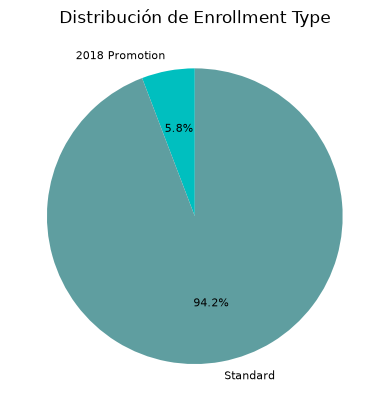

In [42]:
df_enrollment = df_total.groupby("Enrollment Type")["Loyalty Number"].count().reset_index()

colores = ["c", "cadetblue"]
plt.pie("Loyalty Number", data=df_enrollment, labels="Enrollment Type", autopct="%1.1f%%", colors=colores, textprops={"fontsize":8}, startangle=90)
plt.title("Distribución de Enrollment Type")
plt.show()

El 94.2% de los clientes se inscribió de forma estándar, y solo un 5.8% a través de la promoción de 2018, lo que sugiere que la promoción del 2018 no tuvo mucho impacto en la captación de nuevos miembros.

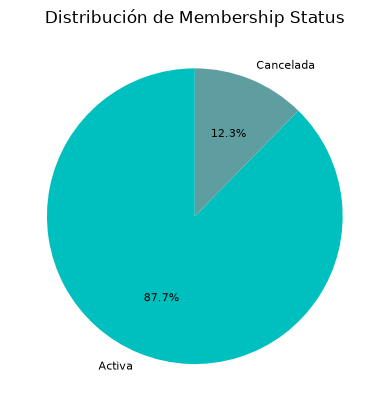

In [43]:
df_membership = df_total.groupby("Membership Status")["Loyalty Number"].count().reset_index()

colores = ["c", "cadetblue"]
plt.pie("Loyalty Number", data=df_membership, labels="Membership Status", autopct="%1.1f%%", colors=colores, textprops={"fontsize":8}, startangle=90)
plt.title("Distribución de Membership Status")
plt.show()

El 87.7% de los clientes tiene la membresía activa y solo un 12.3% la ha cancelado, esto indica una tasa de retención alta en el programa de lealtad.

# Fase 3: Visualización

## 1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

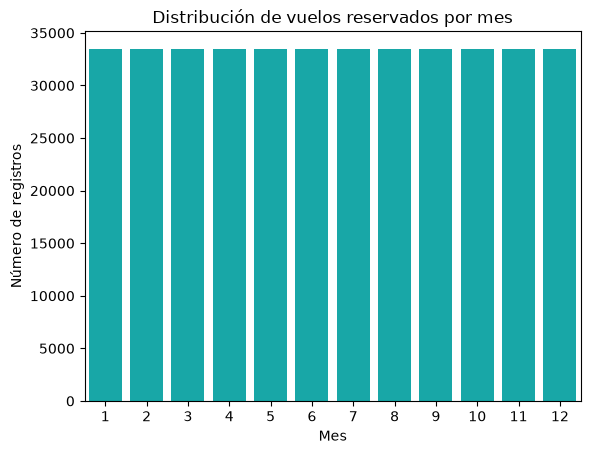

In [ ]:
sns.countplot(x="Month", data=df_total, color="c")
plt.title("Distribución de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Número de registros")
plt.show()

El countplot no nos dice nada, ya que lo que hace es contar cuántas filas hay por mes en el dataset y el dataset tiene registros para todos los clientes en todos los meses, independientemente de si volaron o no.

Así que vamos a visualizarlo mejor en un barplot que nos calcule la media de Flights Booked por mes.

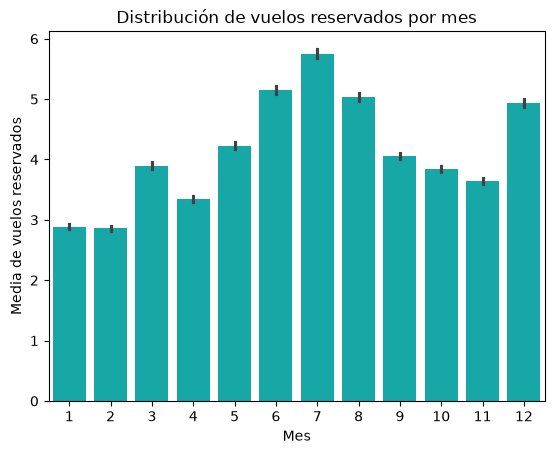

In [51]:
sns.barplot(x="Month", y="Flights Booked", data=df_total, color="c")
plt.title("Distribución de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Media de vuelos reservados")
plt.show()

La actividad de reservas sigue un patrón estacional claro que era de esperar: la temporada alta es en junio, julio y agosto que coincide con las vacaciones de verano, y después existe un repunte en diciembre coincidiendo con las vacaciones de Navidad.

Por otro lado, los meses más flojos son los de invierno (que además son justo después de todos los gastos navideños, o justo antes de Navidad donde la gente ahorra para los gastos que vienen).

## 2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

Con la matriz de correlación que hemos hecho antes, ya hemos podido ver que existía una gran relación entre ellos, pero vamos a verlo en un scatterplot para confirmarlo:

<Axes: xlabel='Distance', ylabel='Points Accumulated'>

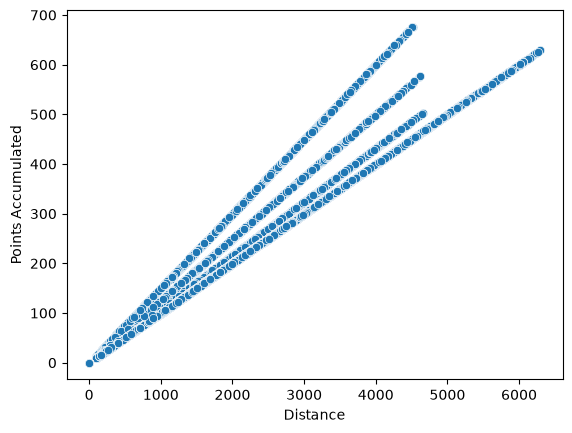

In [52]:
sns.scatterplot(x= 'Distance', y='Points Accumulated', data=df_total)

Se confirma que  existe una relación lineal casi perfecta entre distancia volada y puntos acumulados, lo que confirma que el sistema de puntos se basa directamente en la distancia. 

Las múltiples líneas paralelas sugieren que diferentes tipos de tarjeta tienen distintas tasas de conversión distancia-puntos.

## 3. ¿Cuál es la distribución de los clientes por provincia o estado?

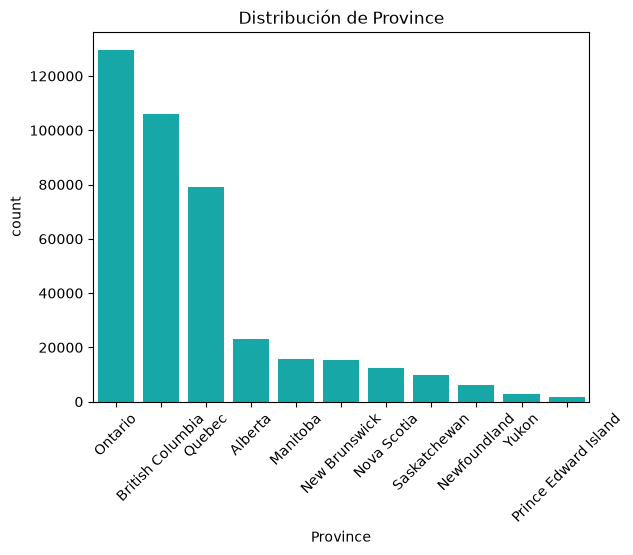

In [53]:
order_province = df_total["Province"].value_counts().index
sns.countplot(x="Province", data=df_total, color="c", order=order_province)
plt.title("Distribución de Province")
plt.xticks(rotation=45)
plt.show()

Dado que esta gráfica ya la tenemos hecha en la fase de análisis categórico, voy a completar un poco más mi respuesta anterior:

Ontario lidera con 129696 registros, seguido de British Columbia (105816) y Quebec (79200). Las tres provincias más pobladas de Canadá concentran la gran mayoría de clientes del programa. 

El resto de provincias tienen presencia marginal. El salto de Quebec a Alberta es enorme.

Conclusión: la distribución de clientes refleja fielmente la distribución poblacional de Canadá y confirma que no existe incidencia especial en las provincias menos pobladas, sino que sucede lo esperable por demografía.

## 4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20680\890831873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Education", y="Salary", data=df_total, palette="magma", order=order_salary)


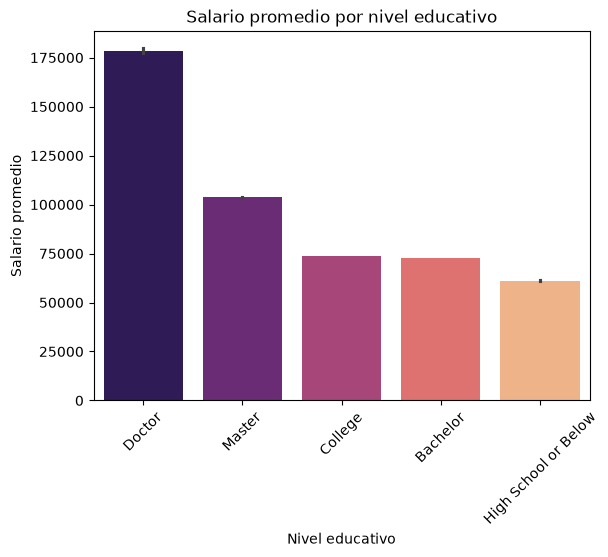

In [56]:
order_salary = df_total.groupby("Education")["Salary"].mean().sort_values(ascending=False).index

sns.barplot(x="Education", y="Salary", data=df_total, palette="magma", order=order_salary)
plt.title("Salario promedio por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario promedio")
plt.xticks(rotation=45)
plt.show()

Podemos ver una correlación clara entre nivel educativo y salario: a mayor formación, mayor salario promedio. 

Doctor lidera con algo más de 175k, casi el doble que Master, que está alrededor de los 100k. College y Bachelor están muy igualados, cerca de los 75k y, por último, High School or Below es el grupo con menor salario promedio entorno a los 60k.

## 5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

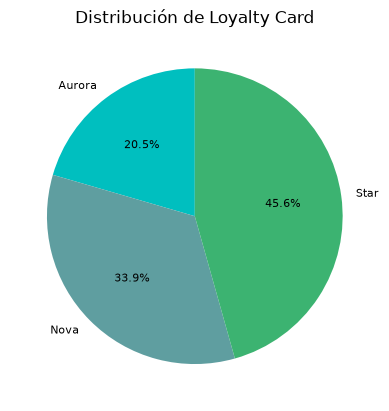

In [57]:
df_loyalty_card = df_total.groupby("Loyalty Card")["Loyalty Number"].count().reset_index()

colores = ["c", "cadetblue", "mediumseagreen"]
plt.pie("Loyalty Number", data=df_loyalty_card, labels="Loyalty Card", autopct="%1.1f%%", colors=colores, textprops={"fontsize":8}, startangle=90)
plt.title("Distribución de Loyalty Card")
plt.show()

Esta gráfica también la tenemos ya hecha en la fase de análisis categórico, así que voy a completar un poco más mi respuesta anterior:

La tarjeta Star es la más común con casi la mitad de los clientes (45.6%), seguida de Nova (33.9%) y Aurora (20.5%), que probablemente es el nivel premium más exclusivo dado que tiene menor proporción de miembros.

Conclusión: la distribución sugiere una estructura de niveles típica de programas de lealtad — la mayoría de clientes está en el nivel base (Star), y los niveles superiores tienen progresivamente menos miembros.

## 6. ¿Cómo se distribuyen los clientes según su estado civil y género?

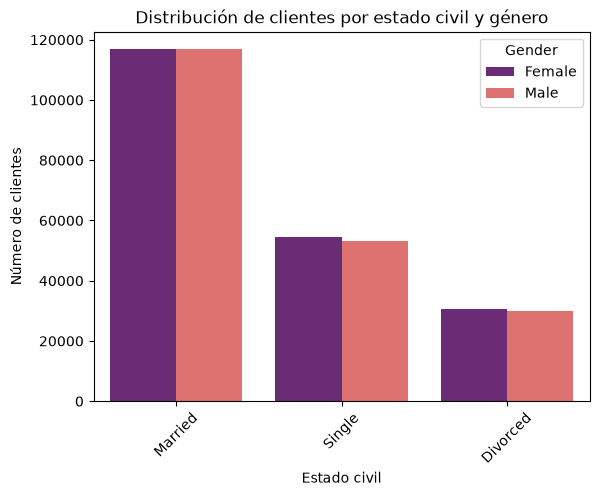

In [58]:
order_marital = df_total["Marital Status"].value_counts().index
sns.countplot(x="Marital Status", data=df_total, order=order_marital, hue="Gender", palette="magma")
plt.title("Distribución de clientes por estado civil y género")
plt.xlabel("Estado civil")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()

En los tres estados civiles la distribución por género es prácticamente idéntica, las barras de Female y Male son casi del mismo tamaño en cada grupo.

Conclusión: además de haber visto anteriormente que la distribución de género de los miembros es prácticamente equitativa, vemos también que el género de los miembros tampoco influye en su estado civil.

# Fase 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo

## 1. Preparación de Datos: Filtra el conjunto de datos para incluir únicamente las columnas relevantes: 'Flights Booked' y 'Education'.

In [59]:
df_reservasxnivel_educativo = df_total[["Flights Booked", "Education"]]
df_reservasxnivel_educativo.head()

,Flights Booked,Education
0,3,Bachelor
1,10,College
2,6,College
3,0,Bachelor
4,0,Bachelor


## 2. Análisis Descriptivo: Agrupa los datos por nivel educativo y calcula estadísticas descriptivas básicas (como el promedio, la desviación estándar) del número de vuelos reservados para cada grupo.

In [60]:
df_reservasxnivel_educativo.groupby("Education")["Flights Booked"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Education,,,,,,,,
Bachelor,251400.0,4.11,5.22,0.0,0.0,1.0,8.0,21.0
College,101712.0,4.17,5.25,0.0,0.0,1.0,8.0,21.0
Doctor,17616.0,4.18,5.26,0.0,0.0,1.0,8.0,21.0
High School or Below,18768.0,4.18,5.25,0.0,0.0,1.0,8.0,21.0
Master,12192.0,4.21,5.22,0.0,0.0,1.0,8.0,21.0


Las diferencias según el nivel educativo son mínimas: la media de vuelos reservados oscila entre 4.11 (Bachelor) y 4.21 (Master), con desviaciones estándar casi idénticas (entre 5.22 y 5.26) y percentiles exactamente iguales en todos los grupos. 

Podemos deducir que todos los grupos se comportan de forma prácticamente idéntica.

Vamos a verlo más claramente con un boxplot. Veremos que las gráficas van a ser idénticas en todos los casos.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20680\4223368392.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="Education", x="Flights Booked", data=df_reservasxnivel_educativo, palette="mako")


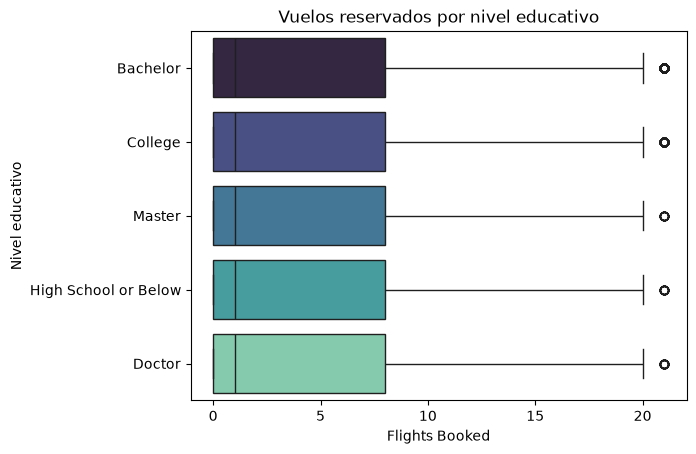

In [63]:
sns.boxplot(y="Education", x="Flights Booked", data=df_reservasxnivel_educativo, palette="mako")
plt.title("Vuelos reservados por nivel educativo")
plt.ylabel("Nivel educativo")
plt.xlabel("Flights Booked")
plt.show()